In [1]:
import globals
import numpy as np
import nibabel as nb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import PcmPy as pcm
import warnings
import globals as gl
import rsatoolbox as rsa
warnings.filterwarnings('ignore')

plt.style.use('default')
plt.style.use('dark_background')

Base directory found: /cifs/diedrichsen/data/SensoriMotorPrediction/
Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/


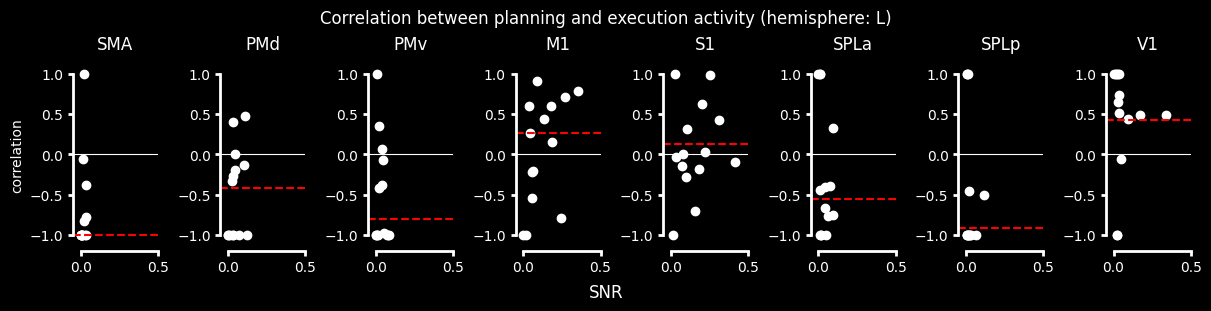

In [2]:
experiment = 'smp2'
glm = 12
H = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
N = 14

Mflex = pcm.CorrelationModel("flex", num_items=1, corr=None, cond_effect=False)

fig, axs = plt.subplots(1, len(rois), sharex=True, figsize=(12, 3), constrained_layout=True)

for r, roi in enumerate(rois):

    T = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_in.corr.glm{glm}.{H}.{roi}.pkl'))
    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.corr.glm{glm}.{H}.{roi}.pkl'), 'rb')
    theta = pickle.load(f)

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_gr.corr.glm{glm}.{H}.{roi}.pkl'), 'rb')
    theta_g = pickle.load(f)

    sigma2_1 = np.exp(theta[0][0])
    sigma2_2 = np.exp(theta[0][1])
    r_indiv = Mflex.get_correlation(theta[0])
    sigma2_e = np.exp(theta[0][3])
    SNR = np.sqrt(sigma2_1*sigma2_2)/sigma2_e
    axs[r].scatter(SNR, r_indiv, color='w')

    theta_g,_= pcm.group_to_individ_param(theta_g[0],Mflex,N)
    r_group = Mflex.get_correlation(theta_g)
    axs[r].axhline(r_group[0], color='r', linestyle='--')
    axs[r].axhline(0, color='w', linestyle='-', lw=.8)
    axs[r].set_title(roi)

    axs[r].set_ylim(-1.2, 1.2)
    axs[r].set_xlim(-.05, .5)

    axs[r].spines[['top', 'right',]].set_visible(False)
    axs[r].spines[['bottom']].set_bounds(0, .5)
    axs[r].spines[['bottom', 'left']].set_linewidth(2)
    axs[r].tick_params(width=2)
    axs[r].spines[['left']].set_bounds(-1, 1)
    # axs[r].tick_params(axis='y', width=0)

    if r==0:
        axs[r].spines[['left']].set_visible(True)

        axs[r].spines[['left']].set_linewidth(2)
        axs[r].tick_params(axis='y', width=2)

fig.supxlabel('SNR')
axs[0].set_ylabel('correlation')

fig.suptitle(f'Correlation between planning and execution activity (hemisphere: {H})')

plt.show()


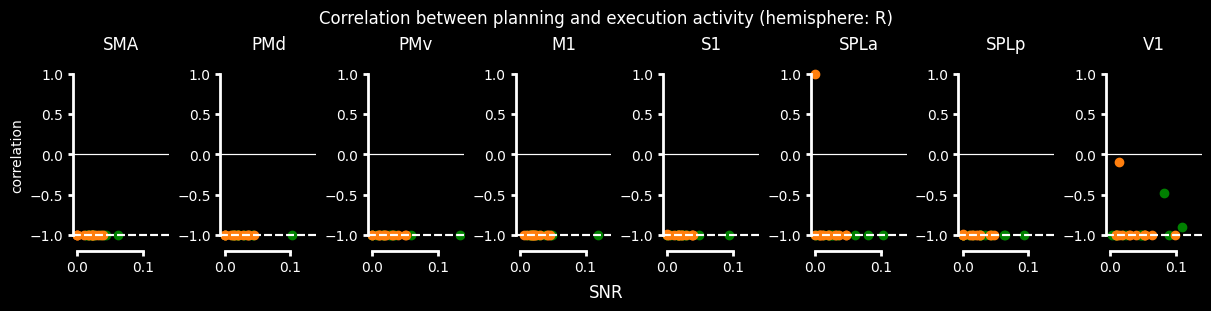

In [9]:
experiment = 'smp2'
glm = 12
H = 'R'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
N = 14

finger = 'index'

Mflex = pcm.CorrelationModel("flex", num_items=1, corr=None, cond_effect=False)

fig, axs = plt.subplots(1, len(rois),  sharex=True, figsize=(12, 3), constrained_layout=True)

for color, finger in zip(['green', 'tab:orange'], ['index', 'ring'], ):
    for r, roi in enumerate(rois):

        T = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_in.corr.{finger}.glm{glm}.{H}.{roi}.pkl'))
        f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.corr.{finger}.glm{glm}.{H}.{roi}.pkl'), 'rb')
        theta = pickle.load(f)

        f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_gr.corr.{finger}.glm{glm}.{H}.{roi}.pkl'), 'rb')
        theta_g = pickle.load(f)

        sigma2_1 = np.exp(theta[0][0])
        sigma2_2 = np.exp(theta[0][1])
        r_indiv = Mflex.get_correlation(theta[0])
        sigma2_e = np.exp(theta[0][3])
        SNR = np.sqrt(sigma2_1*sigma2_2)/sigma2_e
        axs[r].scatter(SNR, r_indiv, color=color)

        theta_g,_= pcm.group_to_individ_param(theta_g[0],Mflex,N)
        r_group = Mflex.get_correlation(theta_g)
        axs[r].axhline(r_group[0], color='w', linestyle='--')
        axs[r].axhline(0, color='w', linestyle='-', lw=.8)
        axs[r].set_title(roi)

        axs[r].set_ylim(-1.2, 1.2)
        # axs[r].set_xlim(-.05, 50)

        axs[r].spines[['top', 'right',]].set_visible(False)
        axs[r].spines[['bottom']].set_bounds(0, .1)
        axs[r].spines[['bottom','left']].set_linewidth(2)
        axs[r].tick_params(width=2)
        # axs[r].tick_params(axis='y', width=0)

        # if r==0:
        # axs[r].spines[['left']].set_visible(True)
        axs[r].spines[['left']].set_bounds(-1, 1)
        # axs[r].spines[['left']].set_linewidth(2)
        # axs[r].tick_params(axis='y', width=2)

fig.supxlabel('SNR')
axs[0].set_ylabel('correlation')

fig.suptitle(f'Correlation between planning and execution activity (hemisphere: {H})')

plt.show()


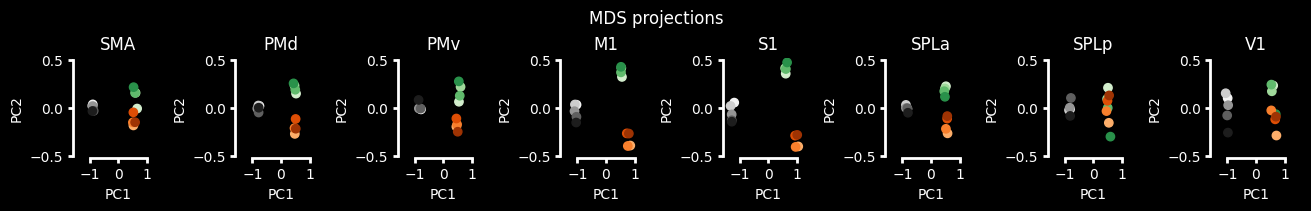

In [7]:
Hem = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']

fig, axs = plt.subplots(1, len(rois), figsize=(13, 2), constrained_layout=True)

corrx = [-1, -1, -1, -1, -1, -1, -1, -1]
corry = [-1, -1, 1,1, 1, 1, 1, -1]

for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.plan-exec.glm{glm}.{Hem}.{roi}.npy')).mean(axis=0)
    mds, _ = pcm.classical_mds(G)

    axs[r].scatter(mds[:, 0] * corrx[r], mds[:, 1] * corry[r], c=list(gl.colour_mapping.values()))
    axs[r].set_title(roi)
    axs[r].set_xlim(-1.6, 1.6)
    axs[r].set_ylim(-.52, .52)
    axs[r].set_ylabel('PC2')
    axs[r].set_xlabel('PC1')
    axs[r].spines[['top', 'right']].set_visible(False)
    axs[r].spines[['bottom', 'left']].set_linewidth(2)
    axs[r].spines[['left',]].set_bounds(-.5, .5)
    axs[r].spines[['bottom',]].set_bounds(-1, 1)
    axs[r].tick_params(width=2)

fig.suptitle(f'MDS projections')

plt.show()

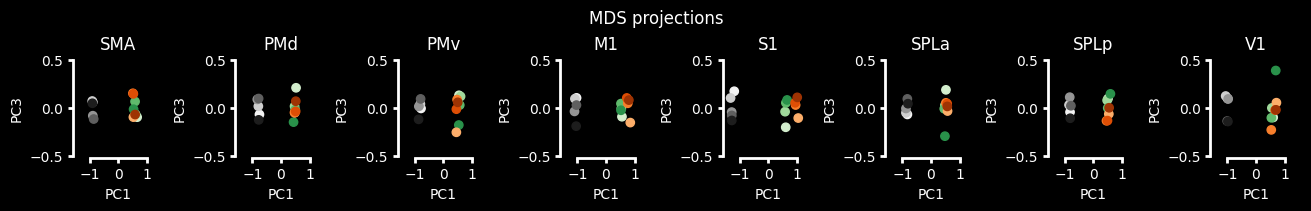

In [5]:
Hem = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']

fig, axs = plt.subplots(1, len(rois), figsize=(13, 2), constrained_layout=True)

corry = [-1, -1, -1, -1, -1, -1, -1, -1]
corrx = [-1, -1, 1, 1, 1, -1, 1, 1]

for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.plan-exec.glm{glm}.{Hem}.{roi}.npy')).mean(axis=0)
    mds, _ = pcm.classical_mds(G)

    axs[r].scatter(mds[:, 0] * corry[r], mds[:, 2] * corrx[r], c=list(gl.colour_mapping.values()))
    axs[r].set_title(roi)
    axs[r].set_xlim(-1.6, 1.6)
    axs[r].set_ylim(-.52, .52)
    axs[r].set_ylabel('PC3')
    axs[r].set_xlabel('PC1')
    axs[r].spines[['top', 'right']].set_visible(False)
    axs[r].spines[['bottom', 'left']].set_linewidth(2)
    axs[r].spines[['left',]].set_bounds(-.5, .5)
    axs[r].spines[['bottom',]].set_bounds(-1, 1)
    axs[r].tick_params(width=2)

fig.suptitle(f'MDS projections')

plt.show()